# 03 — Fit and validate the reduced generators from scratch

This notebook uses the fixed realization-level split: seeds 0–15 for fitting and seeds 16–23 for held-out validation. It fits M0–M3, the autonomous scale extension, and the tensor-corrector alternatives. No frozen coefficient or score file is read.

In [1]:
from pathlib import Path
import os, sys

def find_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "scripts").is_dir():
            return candidate
    raise RuntimeError("Repository root not found. Start Jupyter inside the extracted directory.")

ROOT = find_root(Path.cwd())
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
print("ROOT =", ROOT)


ROOT = /mnt/data/work_release_v3/LagrangianEllipsoid_Corrected_Release_v3/2_github_repository


In [2]:
import json
files=sorted((ROOT/"data"/"raw"/"decisive_k192").glob("*.npz"))
assert len(files)==24, "Finish Notebook 01 first."
split=json.loads((ROOT/"configs"/"train_test_split.json").read_text())
print("Training seeds:", split["train_seeds"])
print("Held-out seeds:", split["test_seeds"])

Training seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Held-out seeds: [16, 17, 18, 19, 20, 21, 22, 23]


In [3]:
import subprocess, time

# The release ships the fitted M0--M3 products and corrected tensor-corrector
# outputs. Set REFIT=True to repeat the complete, computationally expensive
# model-identification stage from the saved trajectories.
REFIT = False
MODEL_SCRIPTS=["fit_generator_hierarchy.py","fit_autonomous_model.py","fit_tensor_corrector.py"]

if REFIT:
    for name in MODEL_SCRIPTS:
        print("\nRunning",name)
        t0=time.time()
        proc=subprocess.run([sys.executable,str(ROOT/"scripts"/name)],cwd=ROOT,text=True,
                            stdout=subprocess.PIPE,stderr=subprocess.STDOUT)
        print(proc.stdout[-7000:])
        if proc.returncode:
            raise RuntimeError(f"{name} failed")
        print(f"Completed in {(time.time()-t0)/60:.1f} min")
else:
    required=[
        ROOT/"data/results/intrinsic_model_b_summary.json",
        ROOT/"data/results/final_intrinsic_model_summary.json",
        ROOT/"data/results/tensor_corrector_model_summary.json",
    ]
    missing=[x for x in required if not x.exists()]
    if missing:
        raise RuntimeError("Saved model products are missing; set REFIT=True after completing the trajectory and analysis notebooks.")
    print("Using shipped fitted products. Set REFIT=True to refit M0--M3 and the tensor corrector from the saved trajectories.")


Using shipped fitted products. Set REFIT=True to refit M0--M3 and the tensor corrector from the saved trajectories.


In [4]:
import json, pandas as pd
intrinsic=json.loads((ROOT/"data"/"results"/"intrinsic_model_b_summary.json").read_text())
rows=[]
for model,score in intrinsic["scores"].items():
    rows.append({"model":model,**{k:v for k,v in score.items() if not isinstance(v,list)}})
display(pd.DataFrame(rows).set_index("model"))

auto=json.loads((ROOT/"data"/"results"/"final_intrinsic_model_summary.json").read_text())
print("Autonomous conditional-sigma RMSE:")
display(pd.DataFrame(auto["autonomous_scores"]).T)

,one_step_nll,one_step_rmse,rollout_mean_sigma_rmse
model,,,
M0,0.914923,0.766345,0.541965
M1,0.882840,0.745876,0.795752
M2,0.811899,0.740105,0.408015
M3,0.815894,0.739046,0.408105


Autonomous conditional-sigma RMSE:


,conditional_sigma,conditional_sigma_rmse
M0,"[0.5320212293108822, 0.6118620608261373, 0.455...",0.360806
M1,"[0.9397125749564751, 1.6766529456219466, 1.761...",0.747134
M2,"[0.7358688692183465, 0.8600065705777343, 0.777...",0.094679
M3,"[0.7386742130323662, 0.8645803316935222, 0.781...",0.09299


B4_intrinsic_hierarchy_sigma.png


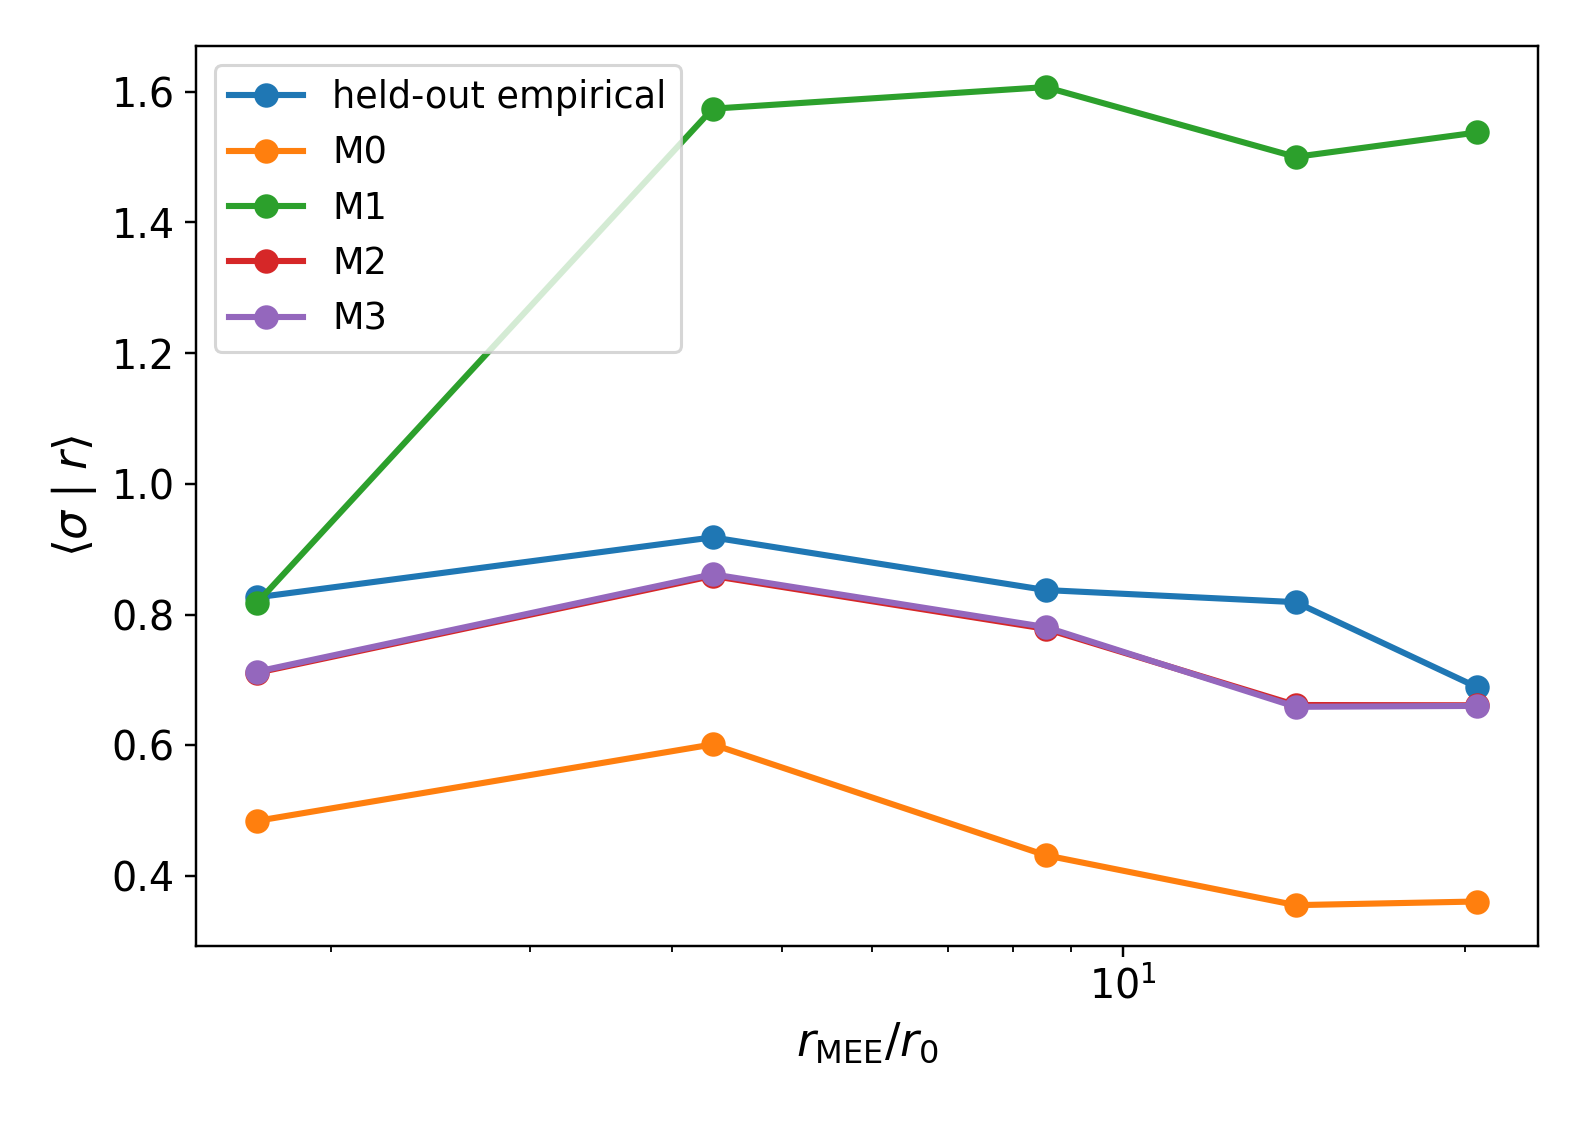

B4_intrinsic_hierarchy_source.png


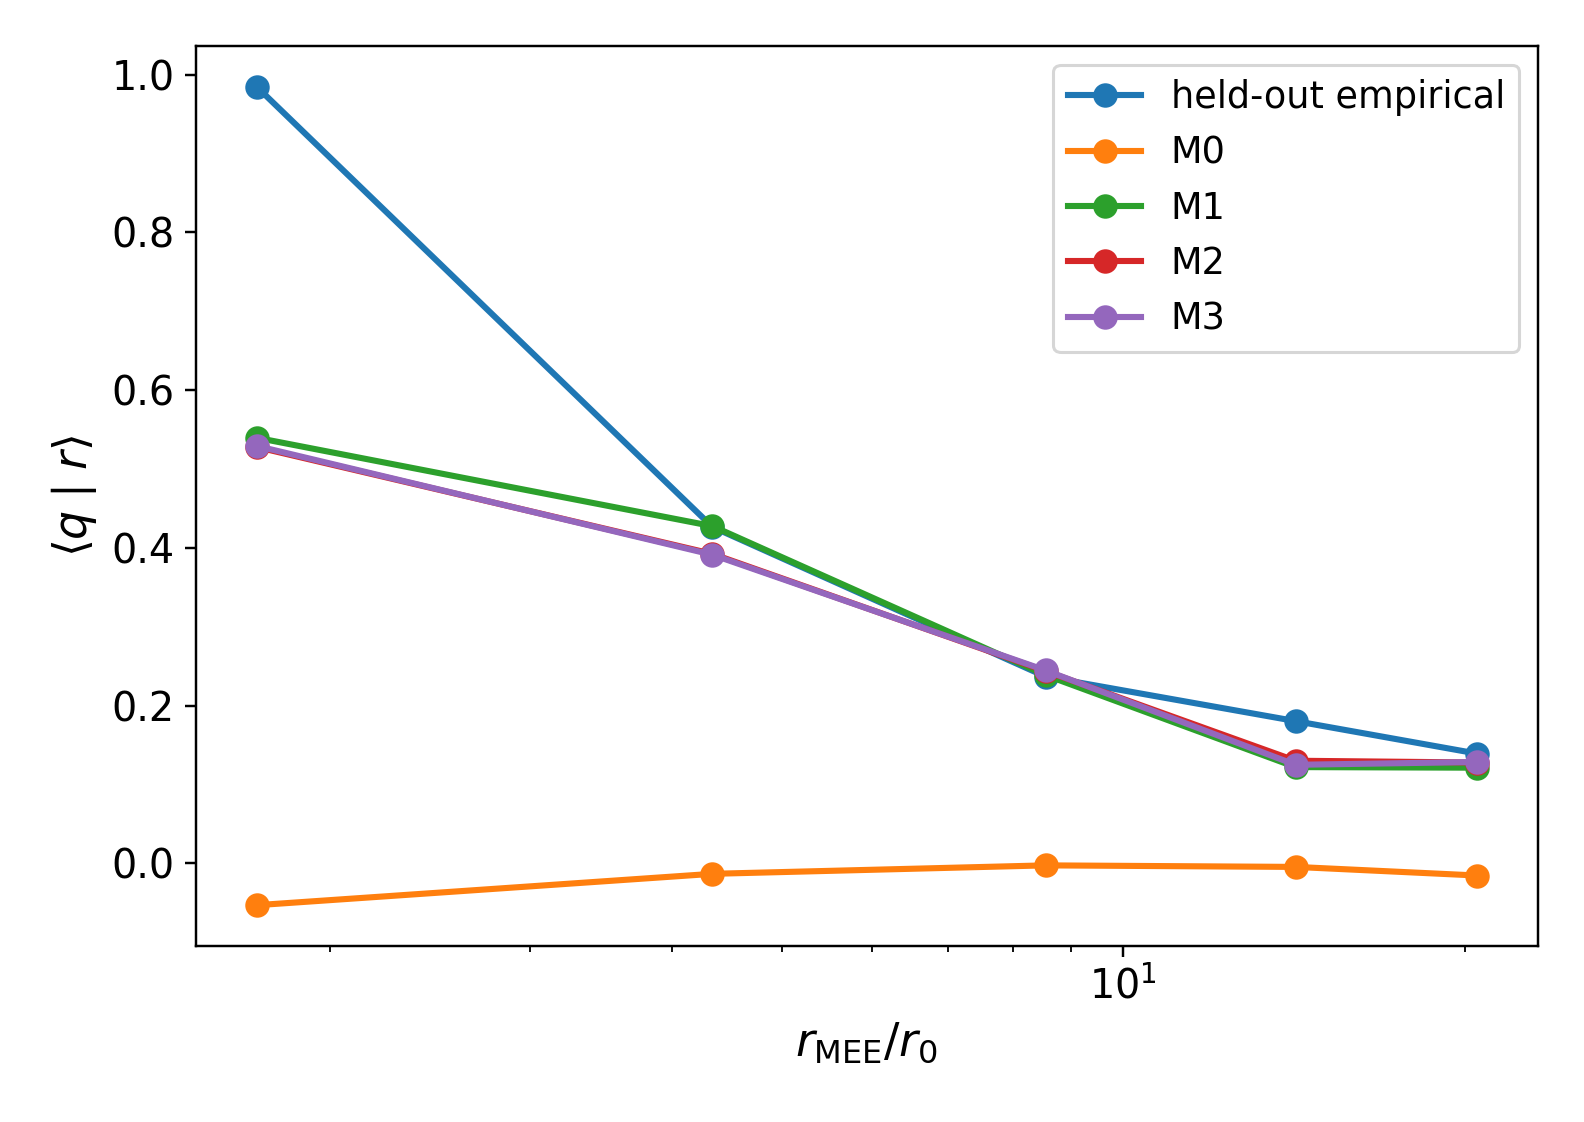

B4_intrinsic_hierarchy_scores.png


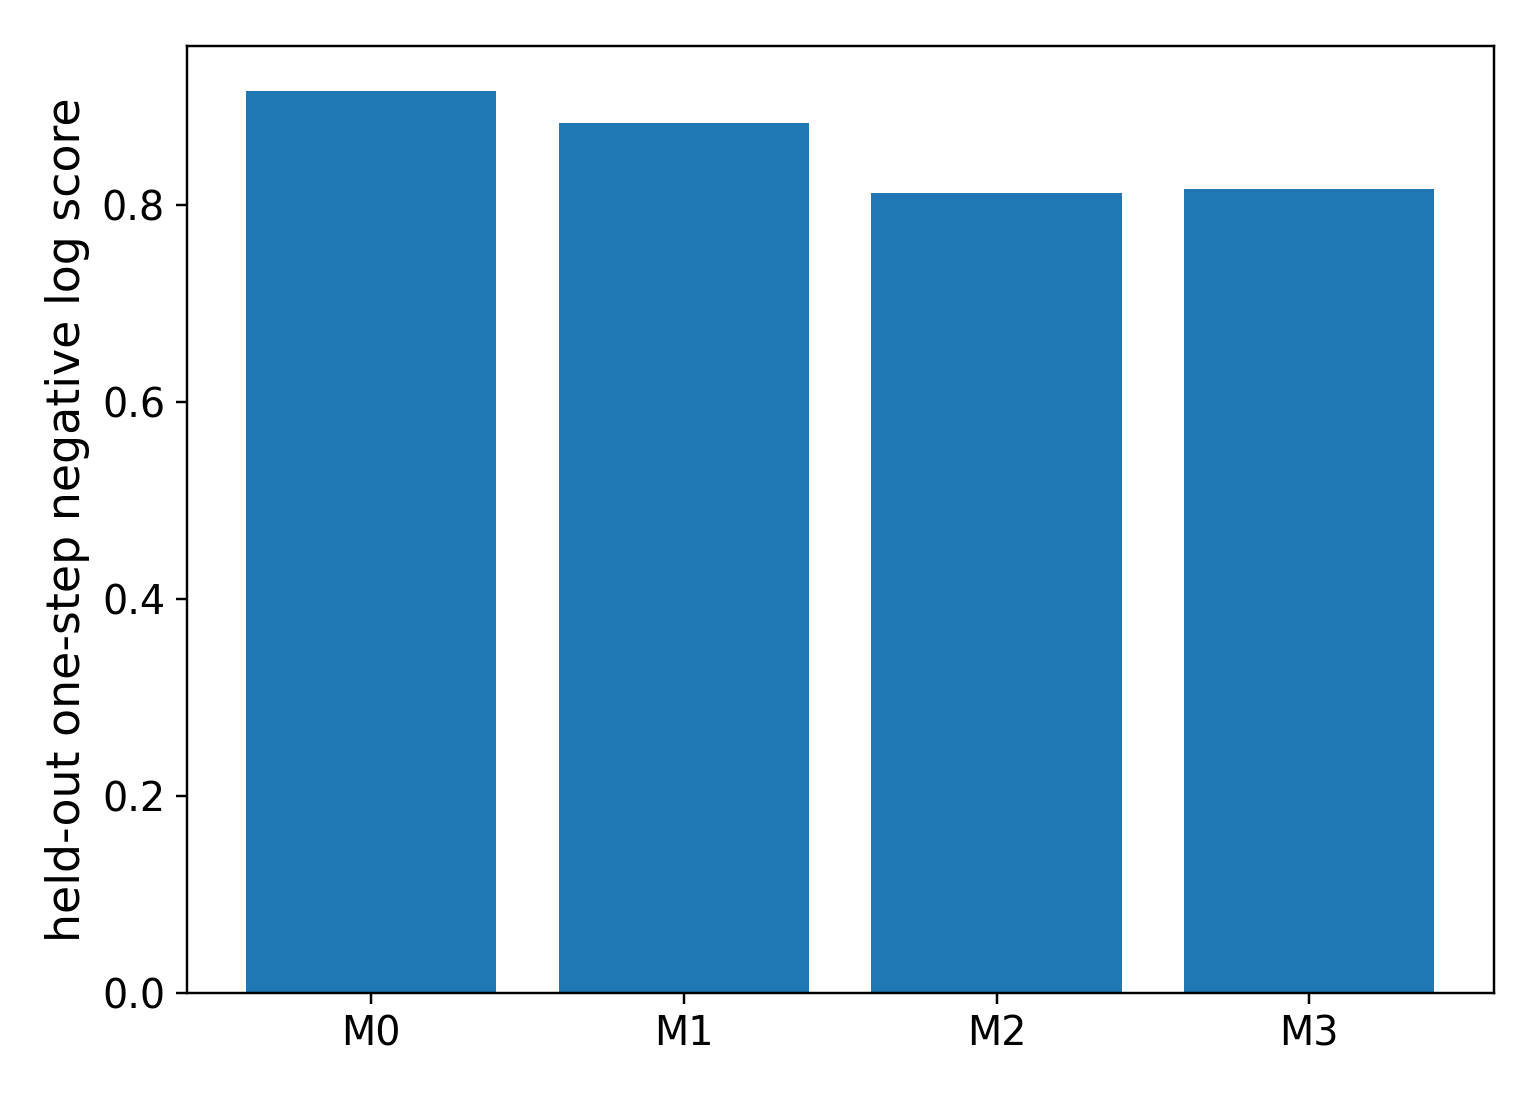

B4_intrinsic_hierarchy_rollout.png


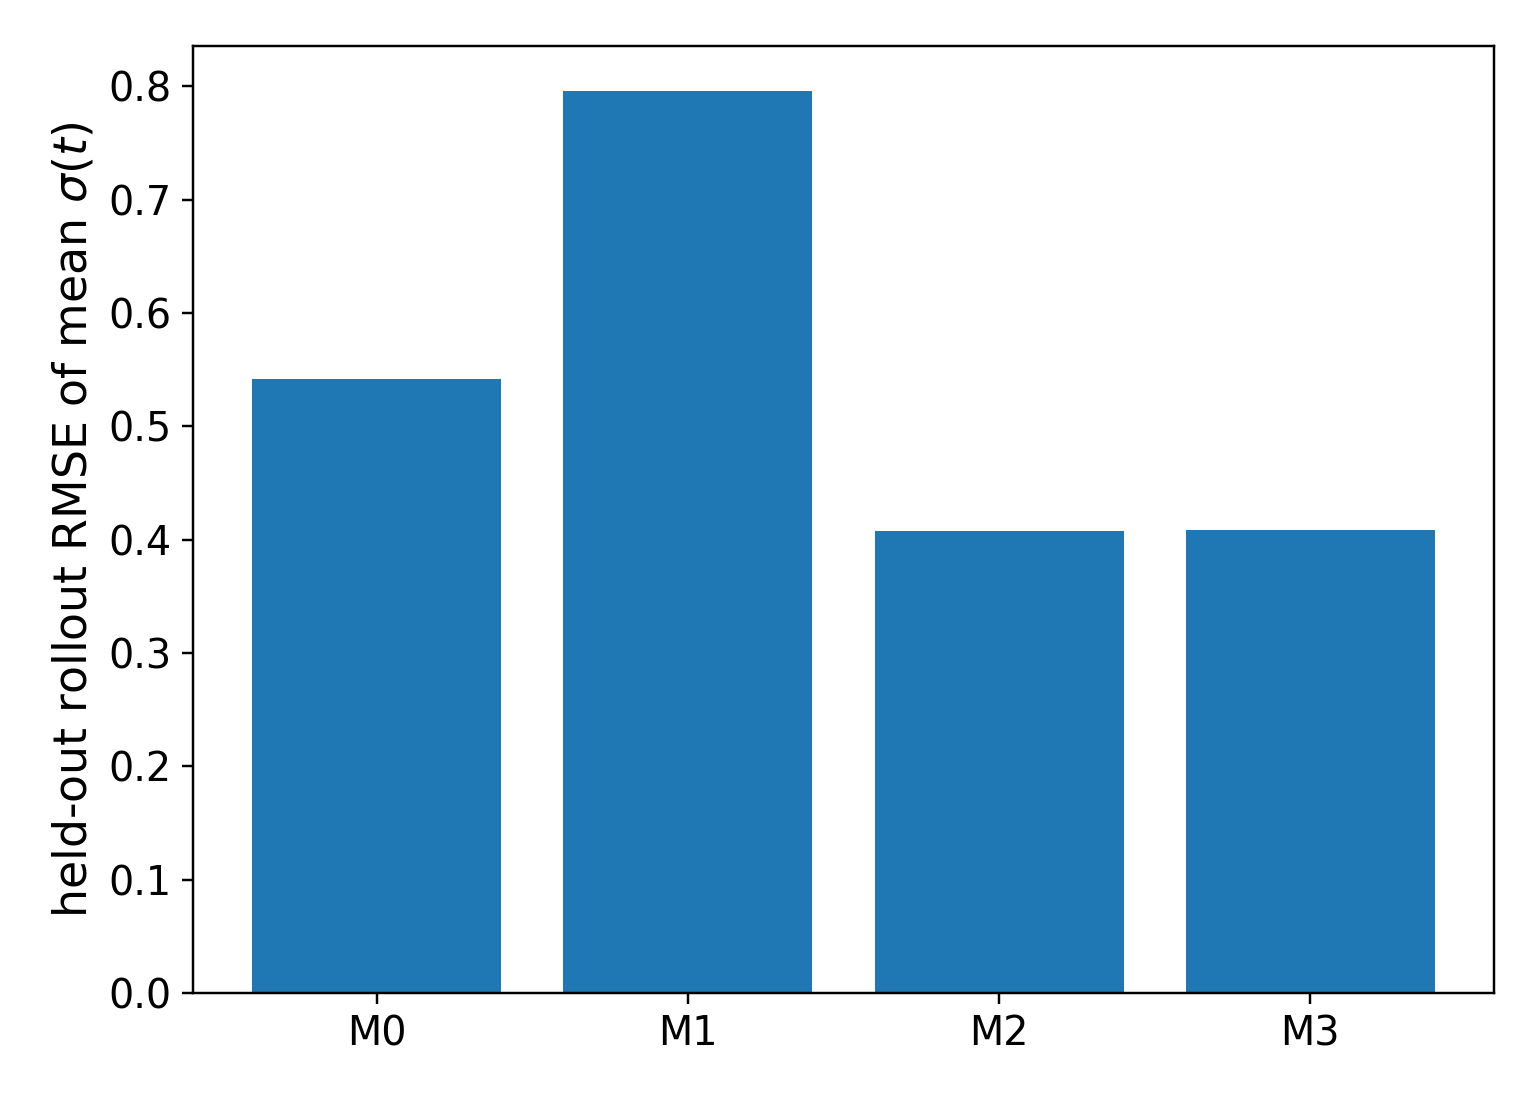

In [5]:
from IPython.display import display, Image
for name in ["B4_intrinsic_hierarchy_sigma.png","B4_intrinsic_hierarchy_source.png",
             "B4_intrinsic_hierarchy_scores.png","B4_intrinsic_hierarchy_rollout.png"]:
    path=ROOT/"figures"/"controls"/name
    print(name); display(Image(filename=str(path)))